# Spectral Folding for ODMR Data

**Spectral folding** exploits the mirror symmetry of ODMR spectra about the zero-field splitting D:

```
f+/- = D +/- gamma * B * cos(theta)
```

The low and high frequency ranges are mirror images about D ~ 2.870 GHz. Averaging them gives:

- **sqrt(2) SNR improvement** in the combined spectrum
- **D_ZFS map** per pixel (temperature/strain proxy)
- **Fold residual** -- a model-free data quality metric

This notebook has two parts:

| Part | Audience | Style |
|------|----------|-------|
| **A. Quick path** | Fry -- "just give me B111 maps" | 3 API calls, done |
| **B. Detailed path** | Lila -- "I need to tweak settings" | Manual SpectralFolder, diagnostics, custom fitting |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qdmpy_core.measurement import Measurement
from qdmpy_core.constants import D_ZFS, D_ZFS_TEMP_COEFFICIENT
from qdmpy_core.odmr import FoldingSettings

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

2026-03-01 08:04:36.049 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESR14N
2026-03-01 08:04:36.049 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESR15N
2026-03-01 08:04:36.050 | INFO     | qdmpy_core.fitting.models:register:395 - Registered model: ESRSINGLE


## Load data

We load the MIL2_FOV1 dataset, 4x4 spatially binned for speed.
Both Part A and Part B use the same `Measurement` object -- no extra RAM.

In [2]:
m = Measurement.from_folder('../tests/data/MIL2_FOV1', bin_factor=4, normalize=True)
data = m.odmr.processed_data.data
freq_ghz = data.coords['freq_ghz'].values   # (n_frange, n_freq)

print(f'Shape:      {data.shape}  (pol, frange, y, x, freq)')
print(f'Freq low:   {freq_ghz[0, 0]:.4f} - {freq_ghz[0, -1]:.4f} GHz')
print(f'Freq high:  {freq_ghz[1, 0]:.4f} - {freq_ghz[1, -1]:.4f} GHz')

2026-03-01 08:04:36.695 | INFO     | qdmpy_core.measurement:from_folder:179 - Loading measurement from ../tests/data/MIL2_FOV1
2026-03-01 08:04:36.696 | INFO     | qdmpy_core.odmr.data:from_loader:87 - Loading ODMR data using loader: MatlabLoader
2026-03-01 08:04:36.696 | INFO     | qdmpy_core.odmr.io:load:82 - Found 2 MATLAB file(s) in ../tests/data/MIL2_FOV1
2026-03-01 08:04:49.916 | INFO     | qdmpy_core.odmr.io:load:151 - MATLAB data loaded in 13.22s — shape (2, 2, 1200, 1920, 51)
2026-03-01 08:04:49.931 | INFO     | qdmpy_core.odmr.manager:process_data:94 - Processing data.
2026-03-01 08:04:49.932 | INFO     | qdmpy_core.odmr.processors:process:344 - Starting processing pipeline.
2026-03-01 08:04:52.125 | INFO     | qdmpy_core.odmr.processors:process:180 - Applying fluorescence correction with factor: 0.2
2026-03-01 08:04:52.450 | INFO     | qdmpy_core.odmr.processors:analyze_fluorescence_effects:242 - Automatically selected pixel index: 23153
2026-03-01 08:04:52.620 | INFO     | 

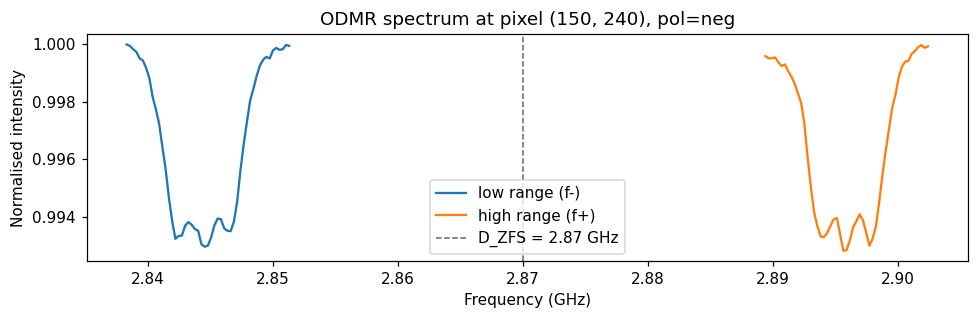

In [3]:
# Inspect a single-pixel ODMR spectrum (low + high ranges)
cy, cx = data.sizes['y'] // 2, data.sizes['x'] // 2

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(freq_ghz[0], data.sel(polarity='neg', freq_range='low').values[cy, cx],
        'tab:blue', lw=1.5, label='low range (f-)')
ax.plot(freq_ghz[1], data.sel(polarity='neg', freq_range='high').values[cy, cx],
        'tab:orange', lw=1.5, label='high range (f+)')
ax.axvline(D_ZFS, color='0.4', ls='--', lw=1, label=f'D_ZFS = {D_ZFS} GHz')
ax.set(xlabel='Frequency (GHz)', ylabel='Normalised intensity',
       title=f'ODMR spectrum at pixel ({cy}, {cx}), pol=neg')
ax.legend()
plt.tight_layout()
plt.show()

The two dips are roughly symmetric about D_ZFS. Folding them together about the
correct D gives a single dip on a Zeeman-offset axis `delta_f` with sqrt(2)
better SNR.

---

# Part A: Quick path (Fry)

Three calls: `fold_odmr()` -> diagnostic check -> `fit_folded_odmr()`.

## A1. Fold

`m.fold_odmr()` runs the full two-scale folding pipeline and caches the result.
Default settings work well for most datasets.

In [4]:
folded = m.fold_odmr()

print(f'Folded spectrum: shape={tuple(folded.folded_spectrum.shape)}')
print(f'D_ZFS map:       shape={tuple(folded.d_zfs_map.shape)}')
print(f'Fold residual:   shape={tuple(folded.fold_residual.shape)}')

2026-03-01 08:04:52.875 | INFO     | qdmpy_core.measurement:fold_odmr:366 - Folding ODMR spectra (bin_factor=8, search_steps=201)
2026-03-01 08:04:54.343 | INFO     | qdmpy_core.measurement:fold_odmr:375 - Spectral folding complete
Folded spectrum: shape=(2, 300, 480, 48)
D_ZFS map:       shape=(2, 300, 480)
Fold residual:   shape=(2, 300, 480)


## A2. Diagnostic check

`folded.plot()` gives a 2x2 overview: search landscape (did the brute-force
find a clean minimum?), D_ZFS deviation map, and fold residual map.

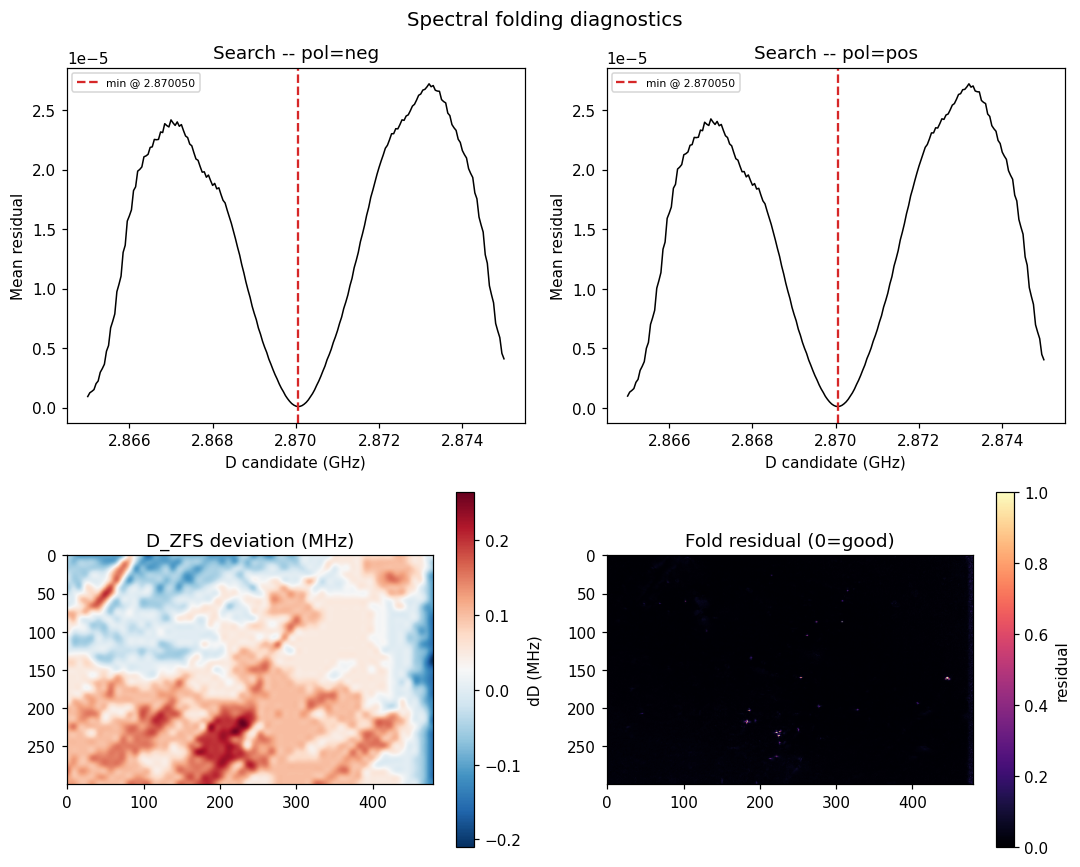

In [5]:
folded.plot()

## A3. Fit and extract B111

`fit_folded_odmr()` uses the cached folded data. The folded spectrum's frequency
axis is already a Zeeman offset, so the fitted centre IS `delta_f` directly --
no D_ZFS subtraction needed for B111 maps.

In [ ]:
qdm_result = m.fit_folded_odmr()

print(f'B111 remanent: mean={qdm_result.b111_remanent.mean():.1f} uT, '
      f'std={qdm_result.b111_remanent.std():.1f} uT')
print(f'B111 induced:  mean={qdm_result.b111_induced.mean():.1f} uT, '
      f'std={qdm_result.b111_induced.std():.1f} uT')

0 <class 'ctypes.c_ulong'>
1 <class 'ctypes.c_ulong'>
2 <class 'pygpufit.gpufit.LP_c_float'>
3 <class 'pygpufit.gpufit.LP_c_float'>
4 <class 'ctypes.c_int'>
5 <class 'pygpufit.gpufit.LP_c_float'>
6 <class 'pygpufit.gpufit.LP_c_float'>
7 <class 'importlib._bootstrap.LP_c_int'>
8 <class 'ctypes.c_float'>
9 <class 'ctypes.c_int'>
10 <class 'importlib._bootstrap.LP_c_int'>
11 <class 'ctypes.c_int'>
12 <class 'ctypes.c_ulong'>
13 <class 'ctypes.LP_c_char'>
14 <class 'pygpufit.gpufit.LP_c_float'>
15 <class 'importlib._bootstrap.LP_c_int'>
16 <class 'pygpufit.gpufit.LP_c_float'>
17 <class 'importlib._bootstrap.LP_c_int'>
2026-03-01 08:04:54.793 | INFO     | qdmpy_core.measurement:fit_folded_odmr:413 - Starting folded ODMR fitting
2026-03-01 08:04:54.795 | INFO     | qdmpy_core.fitting.guess:guess_model:98 - Trying to detect best fitting model for ODMR data.
2026-03-01 08:04:55.133 | INFO     | qdmpy_core.fitting.guess:guess_model:108 - Detected model: ESR14N
2026-03-01 08:04:55.134 | INFO    

In [ ]:
pixel_um = m.pixel_spacing * 1e6
ny, nx = qdm_result.fit_result.scan_dimensions
ext = [0, nx * pixel_um, ny * pixel_um, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

lim = np.percentile(np.abs(qdm_result.b111_remanent), 98)
im0 = axes[0].imshow(qdm_result.b111_remanent, extent=ext, cmap='RdBu_r',
                      vmin=-lim, vmax=lim)
axes[0].set_title('B111 remanent (uT)')
axes[0].set_xlabel('x (um)')
axes[0].set_ylabel('y (um)')
fig.colorbar(im0, ax=axes[0])

lim_ind = np.percentile(np.abs(qdm_result.b111_induced), 98)
im1 = axes[1].imshow(qdm_result.b111_induced, extent=ext, cmap='RdBu_r',
                      vmin=-lim_ind, vmax=lim_ind)
axes[1].set_title('B111 induced (uT)')
axes[1].set_xlabel('x (um)')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

That's it for the quick path. Three calls: `fold_odmr()`, `plot()`, `fit_folded_odmr()`.

---

# Part B: Detailed path (Lila)

Use `SpectralFolder` directly to control settings, inspect the search landscape,
and verify the fold quality before fitting.

> **RAM note:** `m.odmr.processed_data` returns the same in-memory object that
> `Measurement` already holds -- no data duplication.

## B1. Configure and fold

The key tuning knobs:

| Setting | Default | Effect |
|---------|---------|--------|
| `bin_factor` | 8 | Spatial binning for coarse D search (higher = faster, coarser) |
| `search_steps` | 201 | D candidates over +/-`search_range` (more = finer D resolution) |
| `search_range` | 0.005 GHz | Half-width of D search (+/-5 MHz covers ~135 K range) |
| `min_overlap_points` | 5 | Minimum valid delta_f points per candidate |

In [ ]:
from qdmpy_core.odmr.folding import SpectralFolder

settings = FoldingSettings(
    bin_factor=16,
    search_steps=201,
    search_range=0.005,
)

# Uses the same processed data -- no extra RAM
folder = SpectralFolder(m.odmr.processed_data, settings)
result = folder.fold()

print(f'Folded spectrum: {tuple(result.folded_spectrum.shape)}')
print(f'D_ZFS map:       {tuple(result.d_zfs_map.shape)}')
print(f'delta_f axis:    {result.folded_spectrum.coords["delta_f_ghz"].values[0]*1000:.2f} - '
      f'{result.folded_spectrum.coords["delta_f_ghz"].values[-1]*1000:.2f} MHz '
      f'({result.folded_spectrum.sizes["freq_idx"]} points)')

## B2. Search landscape diagnostic

The brute-force search sweeps D candidates and picks the one that minimises the
low-vs-high mismatch. A clean, single minimum means the search is well-behaved.
Multiple minima or a flat landscape suggests the search range or frequency
coverage may need adjustment.

In [ ]:
from qdmpy_core.plotting import plot_folding_search_landscape
plot_folding_search_landscape(result)

## B3. Mean folded spectrum

The spatially-averaged folded spectrum should show a clear ODMR dip centred at
the Zeeman offset. The antisymmetric component (red) should be near zero --
large antisymmetric residuals indicate D_ZFS estimation errors or asymmetric
line shapes.

In [ ]:
from qdmpy_core.plotting import plot_folding_mean_spectrum
plot_folding_mean_spectrum(result)

## B4. D_ZFS and temperature maps

The per-pixel D_ZFS map doubles as a temperature/strain proxy:
dD/dT = -74 kHz/K, so 1 MHz deviation ~ 13.5 K.

In [ ]:
pixel_um = m.pixel_spacing * 1e6
d_zfs_neg = result.d_zfs_map.sel(polarity='neg').values
delta_T = (d_zfs_neg - D_ZFS) / D_ZFS_TEMP_COEFFICIENT

ny, nx = d_zfs_neg.shape
ext = [0, nx * pixel_um, ny * pixel_um, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow((d_zfs_neg - D_ZFS) * 1000, extent=ext, cmap='RdBu_r')
axes[0].set_title('D_ZFS deviation (pol=neg, MHz)')
axes[0].set_xlabel('x (um)')
axes[0].set_ylabel('y (um)')
fig.colorbar(im0, ax=axes[0], label='dD (MHz)')

im1 = axes[1].imshow(delta_T, extent=ext, cmap='RdBu_r')
axes[1].set_title('Temperature variation dT (K)')
axes[1].set_xlabel('x (um)')
fig.colorbar(im1, ax=axes[1], label='dT (K)')

plt.tight_layout()
plt.show()

print(f'D_ZFS range: {(d_zfs_neg.min()-D_ZFS)*1000:.3f} - {(d_zfs_neg.max()-D_ZFS)*1000:.3f} MHz')
print(f'dT range:    {delta_T.min():.1f} - {delta_T.max():.1f} K')

## B5. Fit the folded spectrum

Pass the manually-created `FoldedODMR` result to `fit_folded_odmr()` via the
`folded=` argument. This lets you use custom settings without overwriting the
Measurement's cached result.

In [ ]:
qdm_result_b = m.fit_folded_odmr(folded=result)

print(f'B111 remanent: mean={qdm_result_b.b111_remanent.mean():.1f} uT, '
      f'std={qdm_result_b.b111_remanent.std():.1f} uT')
print(f'B111 induced:  mean={qdm_result_b.b111_induced.mean():.1f} uT, '
      f'std={qdm_result_b.b111_induced.std():.1f} uT')

## Summary

| Step | Quick (Fry) | Detailed (Lila) |
|------|-------------|----------------|
| Fold | `m.fold_odmr()` | `SpectralFolder(m.odmr.processed_data, settings).fold()` |
| Diagnose | `folded.plot()` | `plot_folding_search_landscape()`, `plot_folding_mean_spectrum()` |
| Fit | `m.fit_folded_odmr()` | `m.fit_folded_odmr(folded=result)` |
| D_ZFS map | `m.folded_odmr.d_zfs_map` | `result.d_zfs_map` |
| B111 | `qdm_result.b111_remanent` | same |

The D_ZFS map also enables temperature/strain mapping:
dD/dT = -74 kHz/K, so 1 MHz of dD ~ 13.5 K.

`FoldedFitResult` computes `B111 = centre / gamma` directly (no D_ZFS subtraction)
because the folded spectrum's frequency axis is already a Zeeman offset delta_f.